# ExoLinker: Full Planetary Profile Generation
This notebook demonstrates how to couple an `exowrap` atmosphere model with a `fuzzycore` interior model to generate a continuous, mathematically rigorous planetary profile.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import our newly built exolinker package!
from exoweave import ExoCoupler, save_converged_model
from exowrap.output import ExoremOut
from fuzzycore import constants as c

# Set matplotlib style for nice scientific plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

In [2]:
target_params = {
    "mass": 1.0,               # Jupiter masses
    "T_irr": 150.0,           # Irradiation temperature (K)
    "T_int": 150.0,            # Intrinsic temperature (K)
    "Met": 0.0,                # Metallicity (log10 Z/Z_solar)
    "core_mass_earth": 10.0,   # Solid core mass in Earth masses
    "iron_fraction": 0.33,     # Earth-like core composition
    "f_sed": 1.0,              # Cloud sedimentation
    "kzz": 8.0,                # Eddy diffusion (log10)
    "sigma_val": 0.0,
    "debug": True
}

# 2. Define the numerical configuration for the solver
config = {
    "resolution": 50,                  
    "max_iterations": 15,              
    "mass_convergence_threshold": 0.01,
    "p_bottom_bar": 1000.0,
    "output_dir": "./outputs/fuzzy vs non fuzzy",

    # --- Resolution Setup ---
    "resolution": 50,           # The fast, iterative solving resolution
    "target_resolution": 500    # The final, 1-time forward pass resolution!
}

In [3]:
# 3. Initialize the Orchestrator
coupler = ExoCoupler(target_params=target_params, config=config)

# 4. Fire the main solver loop! (This will take a few minutes)
print("🚀 Launching ExoLinker...")
results = coupler.run()

if results['status'] == 'converged':
    print(f"\n✅ Success! Converged in {results['iterations']} iterations.")
    print(f"Final T_int: {results['final_params']['T_int']:.1f} K")
    print(f"Final g_1bar: {results['final_params']['g_1bar']:.2f} m/s²")
else:
    print("\n❌ Solver failed to converge. Check the history for details.")


if results['status'] == 'failed':
    # Now this will successfully grab the DataFrame!
    raw_atm = results['atmosphere_raw']
    print("\n--- Failed Run Diagnostics ---")
    
    # Expose the ExoremOut properties
    exo = ExoremOut(raw_atm)
    
    print(f"Atmosphere T_int used: {exo.t_int:.1f} K")
    print(f"Atmosphere Gravity used: {exo.gravity[-1]:.2f} m/s²")
    
    # Find the boundary conditions it tried to pass to fuzzycore
    p_levels_bar = exo.pressure_levels / 1e5
    t_levels = exo.temperature_levels
    
    # Let's see what the temperature is at 100 bar!
    idx_link = np.argmin(np.abs(p_levels_bar - config['p_link_target_bar']))
    
    print(f"Deepest Exorem Boundary: P = {p_levels_bar[idx_link]:.2f} bar, T = {t_levels[idx_link]:.1f} K")


INFO: 🧠 Smart Prior: Found neighbor model (M_1.000_Tirr_150.0_Tint_157.1_Met_0.00_Core_10.0_fsed_1.0_kzz_8.0_0.05sigma.pkl) with parameter distance 0.05
INFO: 💡 Smart Initialization: Guessed g = 24.78 m/s² for M = 1.0 M_Jup
INFO: 🧠 Smart Prior: Found neighbor model (M_1.000_Tirr_150.0_Tint_157.1_Met_0.00_Core_10.0_fsed_1.0_kzz_8.0_0.05sigma.pkl) with parameter distance 0.05
INFO: 
INFO: 🔄 ITERATION 1/15 | Target Mass: 1.0 M_Jup | g: 24.78 m/s²
INFO: ==================================================
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpvdtjz88o/input.nml


INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


🚀 Launching ExoLinker...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpvdtjz88o/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: 🔗 Dynamic Junction: Anchoring to thickest convective block at P = 0.55 bar
INFO: Calculating Z_base and Y_ratio from atmospheric VMRs at 0.5463865498818544 bar.
INFO: 🧪 Chemical Sync: Derived Z_base = 0.0069, Y_ratio = 0.2504 (from X=0.7444, Y=0.2487)



🛑 [FUZZYCORE TRIPWIRE: EXACT INPUTS RECEIVED] 🛑
Trial ID: iter_1 | Mode: gravity
Target Value: 2.47849e+01 [m/s^2]
------------------------------------------------------------
Raw Parameters Dictionary:
  - P_surf: 0.5463865498818544
  - T_surf: 206.15458139063398
  - T_int: 145.76165807574992
  - M_core: 5.972e+25 ⚠️ (MASSIVE NUMBER)
  - M_water: 0.0
  - iron_fraction: 0.33
  - z_base: 0.006909595740304031
  - Y_ratio: 0.2504317911261917
  - sigma_val: 0.05
  - z_profile: ndarray (shape: (100,), mean: 0.073)
  - initial_log_pc: 9.0
  - debug: True

--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
  [Solver] Launching concentric bracket sea

...

🚀 Upgrading simulation to R=500...
💾 Locked P-T profile saved to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/fuzzy vs non fuzzy/high_res_tmp_ae504638/locked_pt_profile.dat
⚡ Executing 0-iteration forward pass...


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpy8jx8opm/outputs/exowrap_run.h5...
INFO: 💾 Permanently saved HDF5 to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/fuzzy vs non fuzzy/high_res_tmp_ae504638/exorem_Tint186.60263841419692_g96.96225962545698.h5
INFO: Simulation complete.
INFO: 🌟 High-resolution upgrade seamlessly injected!
INFO: Stitching profiles at P_link = 0.92 bar
INFO: 🌟 Computing Mega-Catalog Photometry (Using Disk Cache)...


🎉 High-resolution upgrade complete!


INFO: ✅ Successfully computed 101 photometric bands!
INFO: ✅ CONVERGED in 6 iterations!
INFO: 💾 Converged model saved successfully to: /Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/fuzzy vs non fuzzy/target/M_1.000_Tirr_150.0_Tint_186.6_Met_0.00_Core_10.0_fsed_1.0_kzz_8.0_sigma_0.05.pkl



✅ Success! Converged in 6 iterations.
Final T_int: 186.6 K
Final g_1bar: 96.96 m/s²


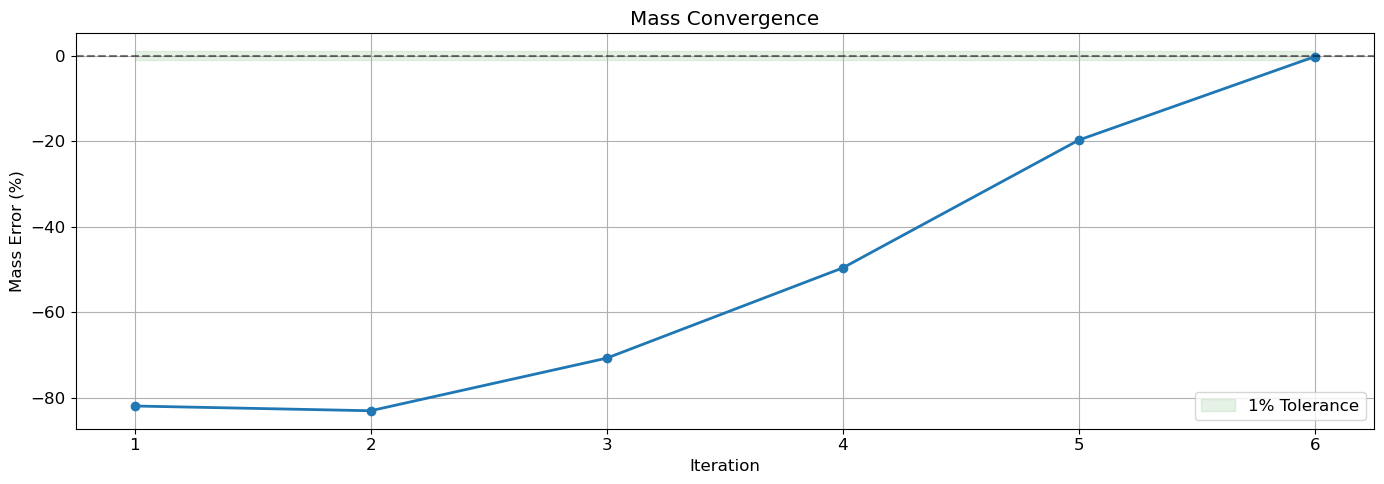

In [4]:
# 5. Visualize the Secant Method at work
history = coupler.history

fig, (ax1) = plt.subplots(1, 1, figsize=(14, 5))

# Gravity Error Plot
ax1.plot(history['iteration'], np.array(history['mass_error']) * 100, marker='o', color='tab:blue', lw=2)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.fill_between(history['iteration'], -1, 1, color='green', alpha=0.1, label="1% Tolerance")
ax1.set_title("Mass Convergence")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Mass Error (%)")
ax1.legend()


plt.tight_layout()
plt.show()

In [5]:
results

{'status': 'converged',
 'iterations': 6,
 'final_params': {'mass': 1.0,
  'T_irr': 150.0,
  'T_int': 186.60263841419692,
  'Met': 0.0,
  'core_mass_earth': 10.0,
  'iron_fraction': 0.33,
  'f_sed': 1.0,
  'kzz': 8.0,
  'sigma_val': 0.05,
  'debug': True,
  'g_1bar': np.float64(96.96225962545698),
  'atmosphere_parameters': {'pressure_max': 100000000.0},
  'paths': {'path_temperature_profile': ''},
  'retrieval_parameters': {'temperature_profile_file': '/Users/cwilkinson/Documents/Work/Research/Research/Codes/exoweave/outputs/fuzzy vs non fuzzy/high_res_tmp_ae504638/locked_pt_profile.dat',
   'n_iterations': 0},
  'z_base': 0.014193249736355384,
  'Y_ratio': 0.25043184063236973,
  'T_int_input_dial': 150.0,
  'true_mass_Mjup': np.float64(0.9977199342659476),
  'p_link_bar': 0.9172759353897791},
 'stitched_profile':       Pressure_Pa  Pressure_bar      Radius_m  Temperature_K  Density_kgm3  \
 0    1.000000e-01  1.000000e-06  3.619140e+07     172.594100  1.625587e-07   
 1    1.295687e-

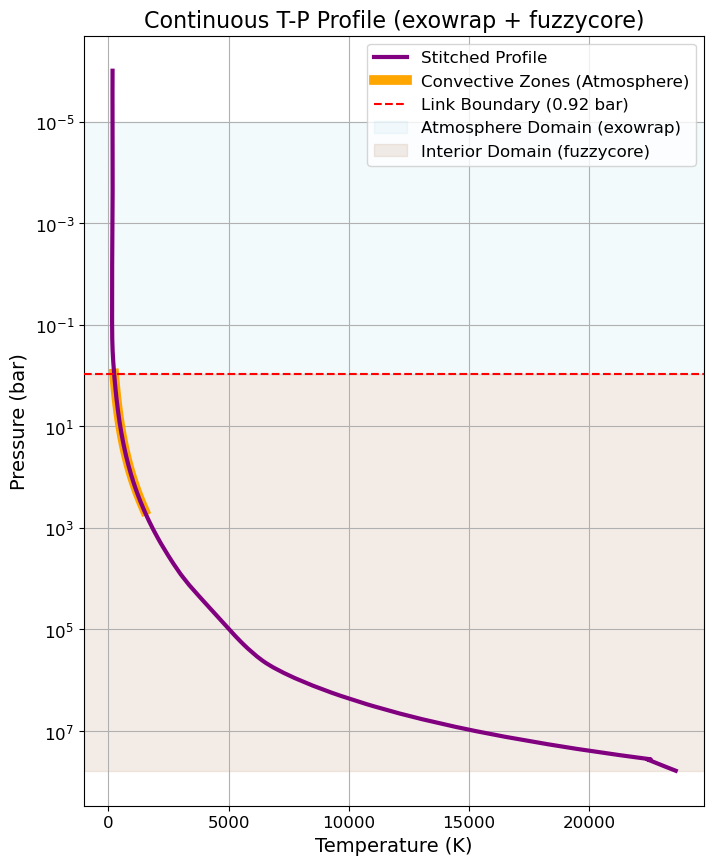

In [21]:
# 6. Visualize the continuous planetary profile
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = results['final_params']['p_link_bar']
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the full stitched profile
    ax.plot(df['Temperature_K'], df['Pressure_bar'], color='purple', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Extract and overlay the convective zones from the atmosphere!
    atm_raw = results['atmosphere_raw']
    p_atm_bar = atm_raw['/outputs/levels/pressure'].iloc[0] / 1e5
    t_atm = atm_raw['/outputs/levels/temperature'].iloc[0]
    is_conv = atm_raw['/outputs/levels/is_convective'].iloc[0].astype(bool)
    
    # Replace all non-convective temperatures with NaN
    t_conv = np.where(is_conv, t_atm, np.nan)
    
    # Plot the bold overlay (Matplotlib automatically skips the NaNs!)
    ax.plot(t_conv, p_atm_bar, color='orange', lw=7, zorder=2, label='Convective Zones (Atmosphere)')
    
    # 3. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 4. Format the axes for atmospheric science standards (log pressure, inverted)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Continuous T-P Profile (exowrap + fuzzycore)", fontsize=16)
    
    # 5. Fill background colors to show domains
    ax.axhspan(1e-5, p_link, color='skyblue', alpha=0.1, label='Atmosphere Domain (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior Domain (fuzzycore)')
    
    ax.legend(loc='upper right')
    plt.show()

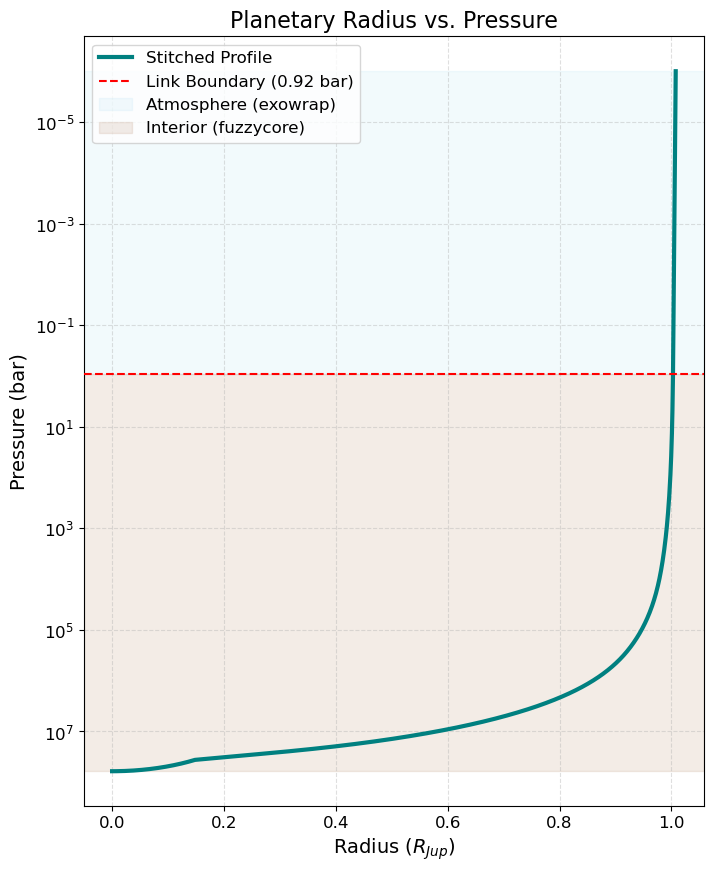

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure we have a converged result to plot
if results['status'] == 'converged':
    df = results['stitched_profile']
    p_link = results['final_params']['p_link_bar']
    
    # Handle column names dynamically (in case your master profile uses meters instead of Jupiter Radii)
    if 'Radius_Rjup' in df.columns:
        r_col = 'Radius_Rjup'
        x_label = "Radius ($R_{Jup}$)"
    elif 'Radius_m' in df.columns:
        # Convert meters to Jupiter radii on the fly (1 R_Jup = 71,492,000 m)
        df['Radius_Rjup_tmp'] = df['Radius_m'] / 71492000.0
        r_col = 'Radius_Rjup_tmp'
        x_label = "Radius ($R_{Jup}$)"
    else:
        # Fallback if standard names aren't found
        r_col = [col for col in df.columns if 'rad' in col.lower()][0]
        x_label = "Radius"
    
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # 1. Plot the continuous Radius vs. Pressure curve
    ax.plot(df[r_col], df['Pressure_bar'], color='teal', lw=3, zorder=3, label='Stitched Profile')
    
    # 2. Draw a line showing exactly where the two models linked
    ax.axhline(p_link, color='red', linestyle='--', zorder=4, label=f'Link Boundary ({p_link:.2f} bar)')
    
    # 3. Format the axes (Log pressure, inverted so the deep core is at the bottom)
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(x_label, fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title("Planetary Radius vs. Pressure", fontsize=16)
    
    # 4. Fill background colors to show physical domains
    ax.axhspan(df['Pressure_bar'].min(), p_link, color='skyblue', alpha=0.1, label='Atmosphere (exowrap)')
    ax.axhspan(p_link, df['Pressure_bar'].max(), color='saddlebrown', alpha=0.1, label='Interior (fuzzycore)')
    
    # Add a grid for easier reading of specific depths
    plt.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(loc='upper left')
    
    plt.show()
else:
    print("The model did not converge. Please check the logs!")

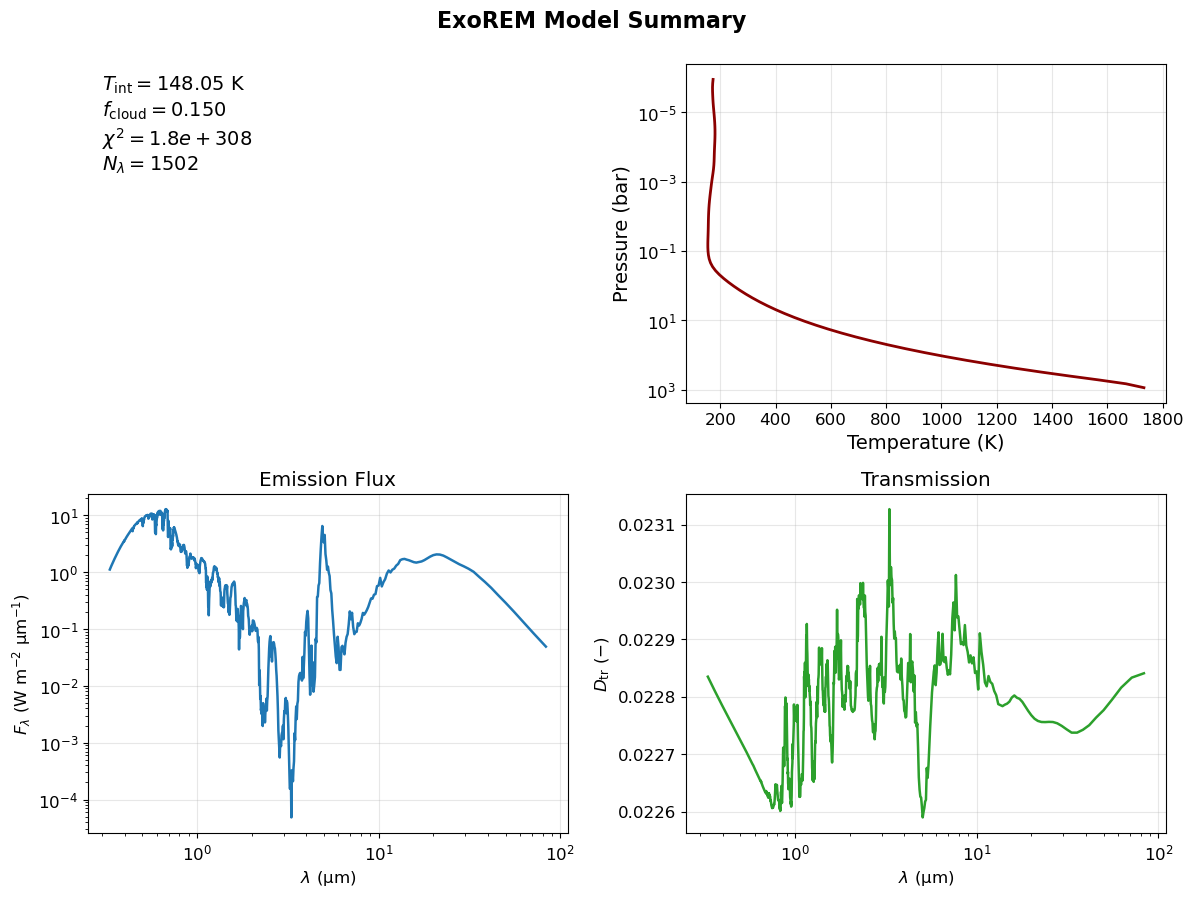

In [23]:
import matplotlib.pyplot as plt
from exowrap.plotting import plot_model_summary

if results['status'] == 'converged':
    # Extract the raw ExoREM DataFrame from your converged results
    atm_df = results['atmosphere_raw']
    
    # Generate the full 4-panel summary
    fig, axes = plot_model_summary(atm_df)
    
    plt.show()
else:
    print("The model did not converge, no atmosphere to plot!")

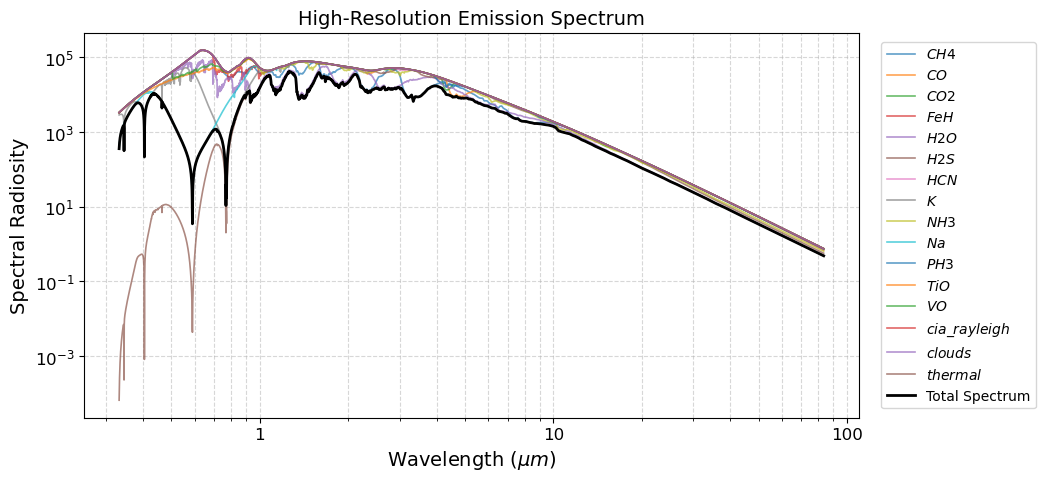

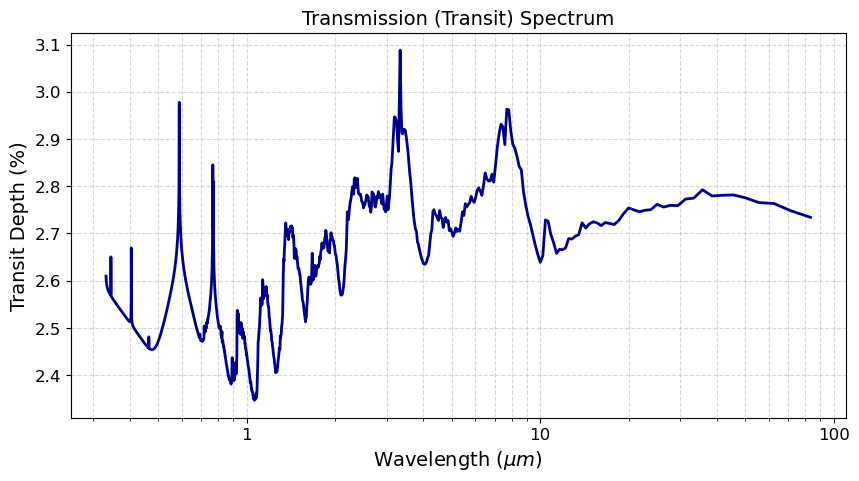

In [14]:
import matplotlib.pyplot as plt
from exowrap.plotting import plot_emission_spectrum, plot_transmission_spectrum

if results['status'] == 'converged':
    atm_df = results['atmosphere_raw']
    
    # 1. Plot the Emission Spectrum (with individual molecular contributions)
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    plot_emission_spectrum(
        results_df=atm_df, 
        ax=ax1, 
        title="High-Resolution Emission Spectrum", 
        color="black",
        contributions=True  # Turns on the background molecular lines!
    )
    plt.show()

    # 2. Plot the Transmission Spectrum
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    plot_transmission_spectrum(
        results_df=atm_df, 
        ax=ax2, 
        title="Transmission (Transit) Spectrum", 
        color="darkblue",
        contributions=False 
    )
    plt.show()